In [6]:
import numpy as np
import gymnasium as gym
from itertools import product, combinations_with_replacement
from gymnasium.wrappers import RecordVideo
import matplotlib.pyplot as plt

In [ ]:
class PolynomialBasis_old:
    def __init__(self, order=2):
        self.order = order
    
    def transform(self, state):
        """Transform state using polynomial basis functions up to given order"""
        features = []
        for o in range(1, self.order + 1):
            for combo in product(state, repeat=o):
                features.append(np.prod(combo))
        return np.array(features)

In [7]:
class PolynomialBasis:
    def __init__(self, order=2, state_dim=6):
        """
        Polynomial basis function approximation
        Args:
            order: maximum order of polynomial terms
            state_dim: dimension of state space
        """
        self.order = order
        self.state_dim = state_dim
        self.num_terms = self._calculate_num_terms()
        
    def _calculate_num_terms(self):
        """Calculate number of terms in polynomial expansion"""
        # This includes all terms up to 'order' degree
        # Using combination with replacement formula (n + k - 1 choose k)
        from math import comb
        return comb(self.state_dim + self.order, self.order) - 1  # Subtract 1 to exclude constant term
    
    def transform(self, state):
        """Generate polynomial features for given state"""
        # Normalize state first
        normalized_state = (state - self.env_low) / (self.env_high - self.env_low)
        
        # Generate polynomial features
        features = []
        
        # Include bias term (1)
        features.append(1.0)
        
        # Generate all polynomial combinations up to order
        for degree in range(1, self.order + 1):
            for indices in combinations_with_replacement(range(self.state_dim), degree):
                term = 1.0
                for idx in indices:
                    term *= normalized_state[idx]
                features.append(term)
        
        return np.array(features)
    
    def set_env_bounds(self, low, high):
        """Set environment bounds for normalization"""
        self.env_low = low
        self.env_high = high

In [8]:
class FourierBasis:
    def __init__(self, order=2, state_dim=6):
        self.order = order
        self.state_dim = state_dim
        self.num_terms = (order + 1) ** state_dim
        self.coefficients = self._generate_coefficients()
    
    def _generate_coefficients(self):
        """Generate all possible coefficient vectors up to the given order"""
        coefficients = []
        for combo in product(range(self.order + 1), repeat=self.state_dim):
            coefficients.append(combo)
        return np.array(coefficients)
    
    def transform(self, state):
        """Transform state using Fourier basis functions"""
        # Normalize state to [0,1] range
        normalized_state = (state - self.env_low) / (self.env_high - self.env_low)
        # Apply cosine Fourier transform
        features = np.cos(np.pi * np.dot(self.coefficients, normalized_state))
        return features
    
    def set_env_bounds(self, low, high):
        """Set environment bounds for normalization"""
        self.env_low = low
        self.env_high = high

In [9]:
class SarsaAgent:
    def __init__(self, env, alpha=0.001, gamma=0.99, epsilon=0.1, order=2):
        self.env = env
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # exploration rate
        self.order = order  # order of polynomial basis
        
        # Initialize polynomial basis function transformer
        self.basis = PolynomialBasis(order=order, state_dim=env.observation_space.shape[0])
        
        # Set environment bounds for normalization
        low = env.observation_space.low
        high = env.observation_space.high
        # Adjust bounds for angular velocities which are unbounded in Acrobot
        low[4:] = -4*np.pi  # angular velocity 1
        low[5:] = -9*np.pi  # angular velocity 2
        high[4:] = 4*np.pi  # angular velocity 1
        high[5:] = 9*np.pi  # angular velocity 2
        self.basis.set_env_bounds(low, high)
        
        # Initialize weights for each action
        self.weights = np.zeros((env.action_space.n, self.basis.num_terms + 1))  # +1 for bias term
    
    def get_q_value(self, state, action):
        """Compute Q-value for state-action pair"""
        features = self.basis.transform(state)
        return np.dot(self.weights[action], features)
    
    def choose_action(self, state):
        """Epsilon-greedy action selection"""
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
            return np.argmax(q_values)
    
    def update_weights(self, state, action, reward, next_state, next_action, done):
        """Update weights using SARSA"""
        current_q = self.get_q_value(state, action)
        next_q = 0 if done else self.get_q_value(next_state, next_action)
        td_target = reward + self.gamma * next_q
        td_error = td_target - current_q
        
        features = self.basis.transform(state)
        self.weights[action] += self.alpha * td_error * features
    
    def train(self, episodes=1000, max_steps=500, eval_interval=100):
        """Train the agent"""
        training_rewards = []
        eval_rewards = []
        
        for episode in range(1, episodes + 1):
            state = self.env.reset()[0]
            action = self.choose_action(state)
            total_reward = 0
            done = False
            step = 0
            
            while not done and step < max_steps:
                next_state, reward, done, _, info = self.env.step(action)
                next_action = self.choose_action(next_state)
                
                self.update_weights(state, action, reward, next_state, next_action, done)
                
                state = next_state
                action = next_action
                total_reward += reward
                step += 1
            
            training_rewards.append(total_reward)
            
            # Evaluation phase
            if episode % eval_interval == 0:
                eval_reward = self.evaluate()
                eval_rewards.append(eval_reward)
                print(f"Episode {episode}, Training Reward: {np.mean(training_rewards[-eval_interval:]):.2f}, "
                      f"Eval Reward: {eval_reward:.2f}")
        
        return training_rewards, eval_rewards
    
    def evaluate(self, episodes=10, max_steps=500):
        """Evaluate the agent's performance"""
        total_rewards = []
        
        for _ in range(episodes):
            state = self.env.reset()[0]
            done = False
            total_reward = 0
            step = 0
            
            while not done and step < max_steps:
                action = self.choose_action(state)
                state, reward, done, _, info = self.env.step(action)
                total_reward += reward
                step += 1
            
            total_rewards.append(total_reward)
        
        return np.mean(total_rewards)

In [10]:
def plot_rewards(rewards, window=50):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Episode Reward')
    
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window - 1, len(rewards)), moving_avg, label=f'{window}-Episode Moving Avg', color='orange')
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('SARSA with Polynomial Basis - Acrobot')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Starting training...
Episode 100, Training Reward: -242.32, Eval Reward: -500.00
Episode 200, Training Reward: -185.07, Eval Reward: -237.30
Episode 300, Training Reward: -212.82, Eval Reward: -414.00
Episode 400, Training Reward: -229.55, Eval Reward: -361.70
Episode 500, Training Reward: -208.29, Eval Reward: -143.50
Episode 600, Training Reward: -187.91, Eval Reward: -210.80
Episode 700, Training Reward: -175.41, Eval Reward: -110.90
Episode 800, Training Reward: -151.78, Eval Reward: -137.50
Episode 900, Training Reward: -132.23, Eval Reward: -129.70
Episode 1000, Training Reward: -125.25, Eval Reward: -93.40
Episode 1100, Training Reward: -112.76, Eval Reward: -88.90
Episode 1200, Training Reward: -103.72, Eval Reward: -108.80
Episode 1300, Training Reward: -110.59, Eval Reward: -94.10
Episode 1400, Training Reward: -104.28, Eval Reward: -145.80
Episode 1500, Training Reward: -103.93, Eval Reward: -103.90
Episode 1600, Training Reward: -103.97, Eval Reward: -113.50
Episode 1700, T

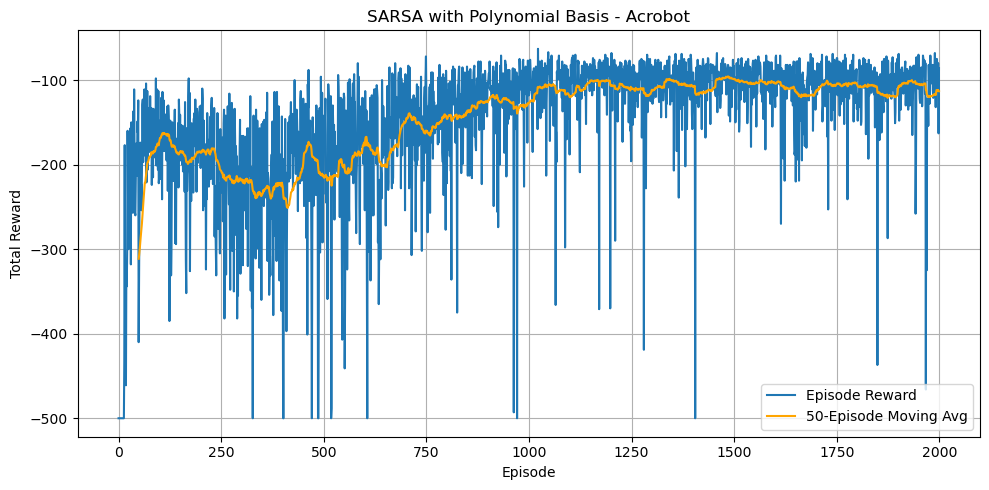


Final evaluation reward (average over 20 episodes): -96.25

Rendering one episode...


c:\Users\anton\anaconda3\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\anton\Desktop\AA\aprendizagem por reforço\algoritmos de ar\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Rendered episode reward: -85.00


In [11]:
 # Create environment
env = gym.make('Acrobot-v1')
    
# Initialize agent with polynomial basis of order 2
agent = SarsaAgent(env, alpha=0.0005, gamma=0.99, epsilon=0.1, order=2)
    
# Train the agent
print("Starting training...")
training_rewards, eval_rewards = agent.train(episodes=2000)
plot_rewards(training_rewards)
    
# Final evaluation
final_reward = agent.evaluate(episodes=20)
print(f"\nFinal evaluation reward (average over 20 episodes): {final_reward:.2f}")

env.close()
    
# Render one episode
print("\nRendering one episode...")
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = RecordVideo(env, './videos')
state = env.reset()[0]
done = False
total_reward = 0
    
while not done:
    action = agent.choose_action(state)
    state, reward, done, _, info = env.step(action)
    total_reward += reward
    env.render()
    
print(f"Rendered episode reward: {total_reward:.2f}")
env.close()